In [11]:
import os
import pandas as pd
import numpy as np
import random
import re
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Download dari Kaggle
import kagglehub
os.environ['KAGGLE_USERNAME'] = 'muhammadyogaisnaeni'
os.environ['KAGGLE_KEY'] = 'bf6873ff2e9847adefe62b75047f2eb0'

path = kagglehub.competition_download('nlp-getting-started')
train_df = pd.read_csv(os.path.join(path, 'train.csv'))
test_df = pd.read_csv(os.path.join(path, 'test.csv'))

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (7613, 5)
Test shape: (3263, 4)


In [12]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [13]:
train_df['target'].value_counts()

,count
target,
0,4342
1,3271


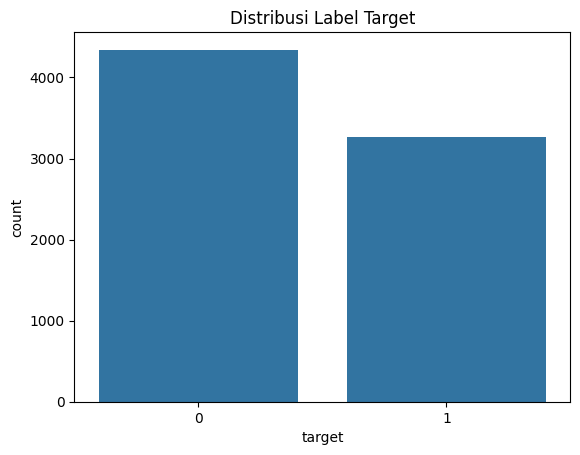

In [14]:
sns.countplot(data=train_df, x='target')
plt.title('Distribusi Label Target')
plt.show()

In [15]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

train_df[['text', 'clean_text', 'target']].head()

,text,clean_text,target
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...,1
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,1
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...,1
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders in ...,1
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...,1


In [16]:
X = train_df['clean_text']
y = train_df['target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

In [17]:
print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)

Train size: (6090,)
Validation size: (1523,)


In [18]:
tfidf_uni = TfidfVectorizer(
    ngram_range=(1, 1),
    max_features=10000
)

X_train_uni = tfidf_uni.fit_transform(X_train)
X_val_uni = tfidf_uni.transform(X_val)

In [19]:
for C in [0.1, 1, 10]:
    model = LogisticRegression(max_iter=1000, C=C, random_state=SEED)
    model.fit(X_train_uni, y_train)
    pred = model.predict(X_val_uni)
    print("C:", C, "F1:", f1_score(y_val, pred))

C: 0.1 F1: 0.6429277942631059
C: 1 F1: 0.7722772277227723
C: 10 F1: 0.7611589663273297


In [20]:
lr_model = LogisticRegression(max_iter=1000, C=1, random_state=SEED)
lr_model.fit(X_train_uni, y_train)

LogisticRegression(C=1, max_iter=1000, random_state=42)

In [21]:
start_train = time.time()

lr_model = LogisticRegression(max_iter=1000, random_state=SEED)
lr_model.fit(X_train_uni, y_train)

end_train = time.time()
lr_train_time = end_train - start_train

In [22]:
start_pred = time.time()

y_pred_lr = lr_model.predict(X_val_uni)

end_pred = time.time()
lr_inference_time = end_pred - start_pred

In [23]:
lr_accuracy = accuracy_score(y_val, y_pred_lr)
lr_precision = precision_score(y_val, y_pred_lr)
lr_recall = recall_score(y_val, y_pred_lr)
lr_f1 = f1_score(y_val, y_pred_lr)

print("Logistic Regression Results")
print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1-score:", lr_f1)
print("Training Time:", lr_train_time)
print("Inference Time:", lr_inference_time)

Logistic Regression Results
Accuracy: 0.8187787261982928
Precision: 0.8387096774193549
Recall: 0.7155963302752294
F1-score: 0.7722772277227723
Training Time: 0.1871175765991211
Inference Time: 0.0012118816375732422


In [24]:
print(classification_report(y_val, y_pred_lr))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       869
           1       0.84      0.72      0.77       654

    accuracy                           0.82      1523
   macro avg       0.82      0.81      0.81      1523
weighted avg       0.82      0.82      0.82      1523



In [25]:
tfidf_bi = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=15000
)

X_train_bi = tfidf_bi.fit_transform(X_train)
X_val_bi = tfidf_bi.transform(X_val)

In [26]:
# Tuning sederhana Linear SVM

for C in [0.1, 1, 10]:
    model = LinearSVC(C=C)
    model.fit(X_train_bi, y_train)
    pred = model.predict(X_val_bi)
    print("C:", C, "F1:", f1_score(y_val, pred))

C: 0.1 F1: 0.7636669470142977
C: 1 F1: 0.759375
C: 10 F1: 0.7312641937925813


In [27]:
svm_model = LinearSVC(C=0.1)
svm_model.fit(X_train_bi, y_train)

LinearSVC(C=0.1)

In [28]:
start_train = time.time()

svm_model = LinearSVC()
svm_model.fit(X_train_bi, y_train)

end_train = time.time()
svm_train_time = end_train - start_train

In [29]:
start_pred = time.time()

y_pred_svm = svm_model.predict(X_val_bi)

end_pred = time.time()
svm_inference_time = end_pred - start_pred

In [30]:
svm_accuracy = accuracy_score(y_val, y_pred_svm)
svm_precision = precision_score(y_val, y_pred_svm)
svm_recall = recall_score(y_val, y_pred_svm)
svm_f1 = f1_score(y_val, y_pred_svm)

print("Linear SVM Results")
print("Accuracy:", svm_accuracy)
print("Precision:", svm_precision)
print("Recall:", svm_recall)
print("F1-score:", svm_f1)
print("Training Time:", svm_train_time)
print("Inference Time:", svm_inference_time)

Linear SVM Results
Accuracy: 0.7977675640183848
Precision: 0.7763578274760383
Recall: 0.7431192660550459
F1-score: 0.759375
Training Time: 0.0484464168548584
Inference Time: 0.0009551048278808594


In [31]:
print(classification_report(y_val, y_pred_svm))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83       869
           1       0.78      0.74      0.76       654

    accuracy                           0.80      1523
   macro avg       0.79      0.79      0.79      1523
weighted avg       0.80      0.80      0.80      1523



In [32]:
start_train = time.time()

nb_model = MultinomialNB()
nb_model.fit(X_train_bi, y_train)

end_train = time.time()
nb_train_time = end_train - start_train

In [33]:
for alpha in [0.1, 0.5, 1.0]:
    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_bi, y_train)
    pred = model.predict(X_val_bi)
    print("alpha:", alpha, "F1:", f1_score(y_val, pred))

alpha: 0.1 F1: 0.7545909849749582
alpha: 0.5 F1: 0.76
alpha: 1.0 F1: 0.7511071744906997


In [34]:
nb_model = MultinomialNB(alpha=0.5)
nb_model.fit(X_train_bi, y_train)

MultinomialNB(alpha=0.5)

In [35]:
start_pred = time.time()

y_pred_nb = nb_model.predict(X_val_bi)

end_pred = time.time()
nb_inference_time = end_pred - start_pred

In [36]:
nb_accuracy = accuracy_score(y_val, y_pred_nb)
nb_precision = precision_score(y_val, y_pred_nb)
nb_recall = recall_score(y_val, y_pred_nb)
nb_f1 = f1_score(y_val, y_pred_nb)

print("Multinomial Naive Bayes Results")
print("Accuracy:", nb_accuracy)
print("Precision:", nb_precision)
print("Recall:", nb_recall)
print("F1-score:", nb_f1)
print("Training Time:", nb_train_time)
print("Inference Time:", nb_inference_time)

Multinomial Naive Bayes Results
Accuracy: 0.8187787261982928
Precision: 0.8810483870967742
Recall: 0.6681957186544343
F1-score: 0.76
Training Time: 0.00489044189453125
Inference Time: 0.0014882087707519531


In [37]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

In [38]:
max_words = 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token='')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')

In [39]:
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [40]:
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

start_train = time.time()

history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

end_train = time.time()
lstm_train_time = end_train - start_train

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5634 - loss: 0.6870 - val_accuracy: 0.5706 - val_loss: 0.6842
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5701 - loss: 0.6847 - val_accuracy: 0.5706 - val_loss: 0.6846
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5703 - loss: 0.6841 - val_accuracy: 0.5706 - val_loss: 0.6841
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5700 - loss: 0.6843 - val_accuracy: 0.5706 - val_loss: 0.6841
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5703 - loss: 0.6845 - val_accuracy: 0.5706 - val_loss: 0.6835
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5701 - loss: 0.6841 - val_accuracy: 0.5706 - val_loss: 0.6833
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5700 - loss: 0.6838 - val_accuracy: 0.5706 - val_loss: 0.6836
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5703 - loss: 0.6837 - val_accuracy:

In [41]:
start_pred = time.time()

y_pred_lstm_prob = lstm_model.predict(X_val_pad)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).reshape(-1)

end_pred = time.time()
lstm_inference_time = end_pred - start_pred

lstm_accuracy = accuracy_score(y_val, y_pred_lstm)
lstm_precision = precision_score(y_val, y_pred_lstm)
lstm_recall = recall_score(y_val, y_pred_lstm)
lstm_f1 = f1_score(y_val, y_pred_lstm)

print("LSTM Results")
print("Accuracy:", lstm_accuracy)
print("Precision:", lstm_precision)
print("Recall:", lstm_recall)
print("F1-score:", lstm_f1)
print("Training Time:", lstm_train_time)
print("Inference Time:", lstm_inference_time)

print(classification_report(y_val, y_pred_lstm))

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
LSTM Results
Accuracy: 0.5705843729481287
Precision: 0.0
Recall: 0.0
F1-score: 0.0
Training Time: 21.666545391082764
Inference Time: 0.40784788131713867
              precision    recall  f1-score   support

           0       0.57      1.00      0.73       869
           1       0.00      0.00      0.00       654

    accuracy                           0.57      1523
   macro avg       0.29      0.50      0.36      1523
weighted avg       0.33      0.57      0.41      1523



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

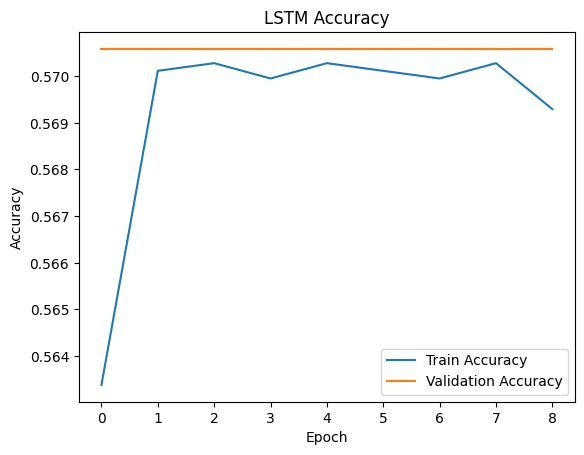

In [42]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

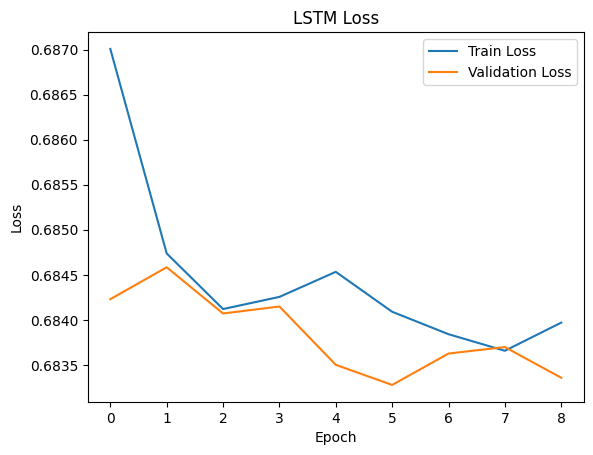

In [43]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [44]:
results = pd.DataFrame({
    'Model': [
        'TF-IDF Unigram + Logistic Regression',
        'TF-IDF Unigram-Bigram + Linear SVM',
        'TF-IDF Unigram-Bigram + Multinomial NB',
        'Embedding + LSTM'
    ],
    'Accuracy': [
        lr_accuracy,
        svm_accuracy,
        nb_accuracy,
        lstm_accuracy
    ],
    'Precision': [
        lr_precision,
        svm_precision,
        nb_precision,
        lstm_precision
    ],
    'Recall': [
        lr_recall,
        svm_recall,
        nb_recall,
        lstm_recall
    ],
    'F1-score': [
        lr_f1,
        svm_f1,
        nb_f1,
        lstm_f1
    ],
    'Training Time': [
        lr_train_time,
        svm_train_time,
        nb_train_time,
        lstm_train_time
    ],
    'Inference Time': [
        lr_inference_time,
        svm_inference_time,
        nb_inference_time,
        lstm_inference_time
    ]
})

results.sort_values(by='F1-score', ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,Training Time,Inference Time
0,TF-IDF Unigram + Logistic Regression,0.818779,0.838710,0.715596,0.772277,0.187118,0.001212
2,TF-IDF Unigram-Bigram + Multinomial NB,0.818779,0.881048,0.668196,0.760000,0.004890,0.001488
1,TF-IDF Unigram-Bigram + Linear SVM,0.797768,0.776358,0.743119,0.759375,0.048446,0.000955
3,Embedding + LSTM,0.570584,0.000000,0.000000,0.000000,21.666545,0.407848


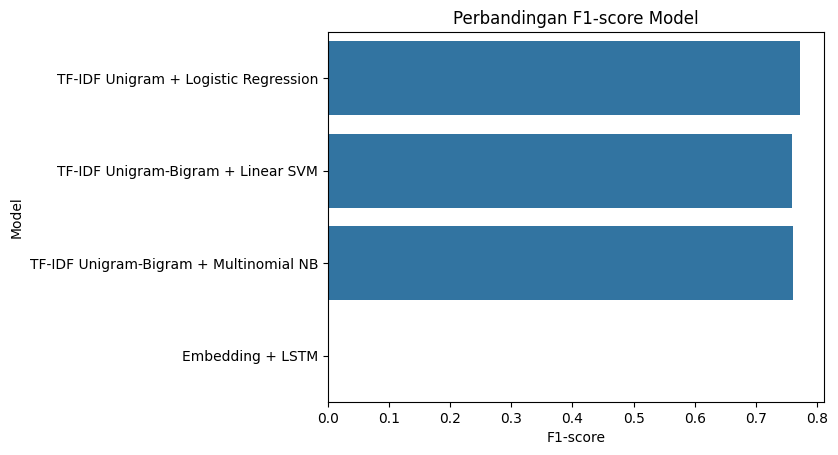

In [45]:
sns.barplot(data=results, x='F1-score', y='Model')
plt.title('Perbandingan F1-score Model')
plt.show()

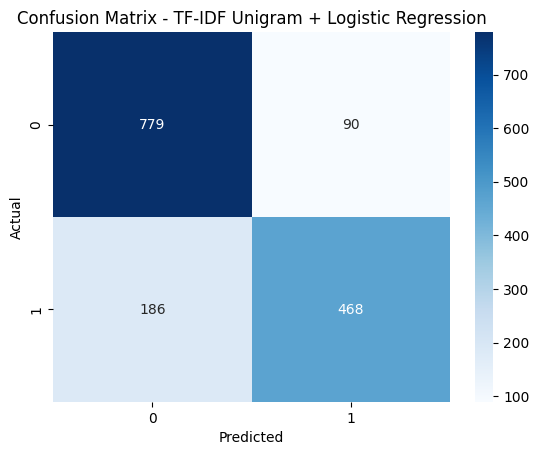

In [46]:
cm = confusion_matrix(y_val, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - TF-IDF Unigram + Logistic Regression')
plt.show()

In [47]:
error_lr = pd.DataFrame({
    'text': X_val.values,
    'actual': y_val.values,
    'predicted': y_pred_lr
})

error_lr = error_lr[error_lr['actual'] != error_lr['predicted']]
error_lr.head(10)

,text,actual,predicted
5,hollywood movie about trapped miners released ...,1,0
6,thu aug gmt utc millcityio theramin sirens,1,0
7,i cant drown my demons they know how to swim,1,0
13,we need these plants in the pacific during the...,1,0
14,if firefighters acted like cops theyd drive ar...,0,1
16,it looks like a mudslide poor thing greatbriti...,1,0
22,on the flip side im at walmart and there is a ...,1,0
24,maybe we should call israel and tell them were...,0,1
27,i agree with certain cultural appropriation th...,1,0
29,the dress memes have officially exploded on th...,1,0


In [48]:
for i, row in error_lr.head(5).iterrows():
    print("Tweet:", row['text'])
    print("Actual:", row['actual'])
    print("Predicted:", row['predicted'])
    print("-" * 80)

Tweet: hollywood movie about trapped miners released in chile the hollywood movie about trapped miners starring
Actual: 1
Predicted: 0
--------------------------------------------------------------------------------
Tweet: thu aug gmt utc millcityio theramin sirens
Actual: 1
Predicted: 0
--------------------------------------------------------------------------------
Tweet: i cant drown my demons they know how to swim
Actual: 1
Predicted: 0
--------------------------------------------------------------------------------
Tweet: we need these plants in the pacific during the cyclone seasons it would help
Actual: 1
Predicted: 0
--------------------------------------------------------------------------------
Tweet: if firefighters acted like cops theyd drive around shooting a flamethrower at burning buildings
Actual: 0
Predicted: 1
--------------------------------------------------------------------------------


In [49]:
error_svm = pd.DataFrame({
    'text': X_val.values,
    'actual': y_val.values,
    'predicted': y_pred_svm
})

error_svm = error_svm[error_svm['actual'] != error_svm['predicted']]
error_svm.head(10)

,text,actual,predicted
0,step one get that mass murderers portrait off ...,0,1
5,hollywood movie about trapped miners released ...,1,0
7,i cant drown my demons they know how to swim,1,0
10,rip the world its burning,0,1
14,if firefighters acted like cops theyd drive ar...,0,1
20,ignition knock detonation sensorsenso standard ks,0,1
22,on the flip side im at walmart and there is a ...,1,0
24,maybe we should call israel and tell them were...,0,1
27,i agree with certain cultural appropriation th...,1,0
29,the dress memes have officially exploded on th...,1,0


In [50]:
for i, row in error_svm.head(10).iterrows():
    print("Tweet:", row['text'])
    print("Actual:", row['actual'])
    print("Predicted:", row['predicted'])
    print("-" * 80)

Tweet: step one get that mass murderers portrait off the yuan
Actual: 0
Predicted: 1
--------------------------------------------------------------------------------
Tweet: hollywood movie about trapped miners released in chile the hollywood movie about trapped miners starring
Actual: 1
Predicted: 0
--------------------------------------------------------------------------------
Tweet: i cant drown my demons they know how to swim
Actual: 1
Predicted: 0
--------------------------------------------------------------------------------
Tweet: rip the world its burning
Actual: 0
Predicted: 1
--------------------------------------------------------------------------------
Tweet: if firefighters acted like cops theyd drive around shooting a flamethrower at burning buildings
Actual: 0
Predicted: 1
--------------------------------------------------------------------------------
Tweet: ignition knock detonation sensorsenso standard ks
Actual: 0
Predicted: 1
--------------------------------------

In [51]:
error_lstm = pd.DataFrame({
    'text': X_val.values,
    'actual': y_val.values,
    'predicted': y_pred_lstm
})

error_lstm = error_lstm[error_lstm['actual'] != error_lstm['predicted']]
error_lstm.head(10)

,text,actual,predicted
2,how little boy affected the people in hiroshim...,1,0
5,hollywood movie about trapped miners released ...,1,0
6,thu aug gmt utc millcityio theramin sirens,1,0
7,i cant drown my demons they know how to swim,1,0
12,something frightening is happening to the weat...,1,0
13,we need these plants in the pacific during the...,1,0
15,dear in the name of humanityi apologized to hi...,1,0
16,it looks like a mudslide poor thing greatbriti...,1,0
17,families to sue over legionnaires disease outb...,1,0
18,still and box alarm for the train derailment a...,1,0


In [52]:
for i, row in error_lstm.head(10).iterrows():
    print("Tweet:", row['text'])
    print("Actual:", row['actual'])
    print("Predicted:", row['predicted'])
    print("-" * 80)

Tweet: how little boy affected the people in hiroshima eyewitness testimonials
Actual: 1
Predicted: 0
--------------------------------------------------------------------------------
Tweet: hollywood movie about trapped miners released in chile the hollywood movie about trapped miners starring
Actual: 1
Predicted: 0
--------------------------------------------------------------------------------
Tweet: thu aug gmt utc millcityio theramin sirens
Actual: 1
Predicted: 0
--------------------------------------------------------------------------------
Tweet: i cant drown my demons they know how to swim
Actual: 1
Predicted: 0
--------------------------------------------------------------------------------
Tweet: something frightening is happening to the weather in the middle east
Actual: 1
Predicted: 0
--------------------------------------------------------------------------------
Tweet: we need these plants in the pacific during the cyclone seasons it would help
Actual: 1
Predicted: 0
----

In [53]:
comparison_error = pd.DataFrame({
    'text': X_val.values,
    'actual': y_val.values,
    'pred_lr': y_pred_lr,
    'pred_svm': y_pred_svm,
    'pred_lstm': y_pred_lstm
})

svm_wrong_lstm_correct = comparison_error[
    (comparison_error['pred_svm'] != comparison_error['actual']) &
    (comparison_error['pred_lstm'] == comparison_error['actual'])
]

svm_wrong_lstm_correct.head(10)


svm_correct_lstm_wrong = comparison_error[
    (comparison_error['pred_svm'] == comparison_error['actual']) &
    (comparison_error['pred_lstm'] != comparison_error['actual'])
]

svm_correct_lstm_wrong.head(10)

,text,actual,pred_lr,pred_svm,pred_lstm
2,how little boy affected the people in hiroshim...,1,1,1,0
6,thu aug gmt utc millcityio theramin sirens,1,0,1,0
12,something frightening is happening to the weat...,1,1,1,0
13,we need these plants in the pacific during the...,1,0,1,0
15,dear in the name of humanityi apologized to hi...,1,1,1,0
16,it looks like a mudslide poor thing greatbriti...,1,0,1,0
17,families to sue over legionnaires disease outb...,1,1,1,0
18,still and box alarm for the train derailment a...,1,1,1,0
26,bomb head explosive decisions dat produced mor...,1,1,1,0
28,suicide bomber kills in saudi security site mo...,1,1,1,0


In [54]:
X_test = test_df['clean_text']
X_test_tfidf = tfidf_uni.transform(X_test)

test_pred = lr_model.predict(X_test_tfidf)

submission = pd.DataFrame({
    'id': test_df['id'],
    'target': test_pred
})

submission.to_csv('submission.csv', index=False)

from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>